In [4]:
# === Section 1: Setup & Imports ===
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal as scipy_signal
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.impute import SimpleImputer
import shap
import warnings
warnings.filterwarnings('ignore')


from functions import load_subject_data, create_windows, stat_features, freq_features, eda_extra_features, extract_window_features

In [5]:
# === Constants ===
DATA_PATH = Path('WESAD')
SUBJECT_IDS = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
LABEL_MAP = {1: 'Baseline', 2: 'Stress', 3: 'Amusement'}
WRIST_SAMPLING_RATES = {'ACC': 32, 'BVP': 64, 'EDA': 4, 'TEMP': 4}
LABEL_SAMPLING_RATE = 700
WINDOW_SIZE_SEC = 30  # 30-second windows
WINDOW_SHIFT_SEC = 5  # 5-second sliding step
VALID_LABELS = [1, 2, 3]
# Binary mapping: 0 = Non-Stress (baseline + amusement), 1 = Stress
BINARY_MAP = {1: 0, 2: 1, 3: 0}
BINARY_LABEL_NAMES = ['Non-Stress', 'Stress']

print(f"Subjects: {SUBJECT_IDS}")
print(f"Window size: {WINDOW_SIZE_SEC}s")

Subjects: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
Window size: 30s


In [6]:
all_subjects_data = {}

for sid in SUBJECT_IDS:
    print(f"Loading S{sid}...", end=" ")
    all_subjects_data[sid] = load_subject_data(DATA_PATH, sid)
    print("OK")

print(f"\nLoaded {len(all_subjects_data)} subjects successfully.")

Loading S2... OK
Loading S3... OK
Loading S4... OK
Loading S5... OK
Loading S6... OK
Loading S7... OK
Loading S8... OK
Loading S9... OK
Loading S10... OK
Loading S11... OK
Loading S13... OK
Loading S14... OK
Loading S15... OK
Loading S16... OK
Loading S17... OK

Loaded 15 subjects successfully.


Section 2 — Data Loading & Exploration

In [7]:
# === Explore structure of one subject ===
sample = all_subjects_data[SUBJECT_IDS[0]]
print(f"Subject: {sample['subject']}")
print(f"Top-level keys: {list(sample.keys())}")
print(f"Signal keys: {list(sample['signal'].keys())}")
print(f"Wrist signal keys: {list(sample['signal']['wrist'].keys())}")

print(f"\nWrist signal shapes:")
for key, val in sample['signal']['wrist'].items():
    sr = WRIST_SAMPLING_RATES[key]
    duration = len(val) / sr
    print(f"  {key}: shape={val.shape}, rate={sr}Hz, duration={duration:.1f}s")

print(f"\nLabel shape: {sample['label'].shape}")
print(f"Label duration: {len(sample['label']) / LABEL_SAMPLING_RATE:.1f}s")

print(f"\nLabel distribution (S{SUBJECT_IDS[0]}):")
unique, counts = np.unique(sample['label'], return_counts=True)
for u, c in zip(unique, counts):
    name = LABEL_MAP.get(int(u), f"Other({int(u)})")
    print(f"  {name}: {c} samples = {c/LABEL_SAMPLING_RATE:.1f}s")


Subject: S2
Top-level keys: ['signal', 'label', 'subject']
Signal keys: ['chest', 'wrist']
Wrist signal keys: ['ACC', 'BVP', 'EDA', 'TEMP']

Wrist signal shapes:
  ACC: shape=(194528, 3), rate=32Hz, duration=6079.0s
  BVP: shape=(389056, 1), rate=64Hz, duration=6079.0s
  EDA: shape=(24316, 1), rate=4Hz, duration=6079.0s
  TEMP: shape=(24316, 1), rate=4Hz, duration=6079.0s

Label shape: (4255300,)
Label duration: 6079.0s

Label distribution (S2):
  Other(0): 2142701 samples = 3061.0s
  Baseline: 800800 samples = 1144.0s
  Stress: 430500 samples = 615.0s
  Amusement: 253400 samples = 362.0s
  Other(4): 537599 samples = 768.0s
  Other(6): 45500 samples = 65.0s
  Other(7): 44800 samples = 64.0s


In [8]:
# === Dataset statistics across all subjects ===
stats_rows = []
for sid in SUBJECT_IDS:
    labels = all_subjects_data[sid]['label'].flatten()
    for lv in VALID_LABELS:
        count = int(np.sum(labels == lv))
        stats_rows.append({
            'Subject': f'S{sid}',
            'Class': LABEL_MAP[lv],
            'Duration_s': round(count / LABEL_SAMPLING_RATE, 1)
        })

stats_df = pd.DataFrame(stats_rows)
pivot = stats_df.pivot_table(index='Subject', columns='Class', values='Duration_s')
print("Duration per class per subject (seconds):")
print(pivot.to_string())
print(f"\nTotal per class:\n{stats_df.groupby('Class')['Duration_s'].sum()}")


Duration per class per subject (seconds):
Class    Amusement  Baseline  Stress
Subject                             
S10          372.0    1180.0   725.0
S11          368.0    1180.0   680.0
S13          382.0    1180.0   664.0
S14          372.0    1180.0   675.0
S15          372.0    1175.0   686.0
S16          368.0    1180.0   673.0
S17          372.0    1181.0   723.0
S2           362.0    1144.0   615.0
S3           375.0    1140.0   640.0
S4           372.0    1158.0   635.0
S5           374.0    1198.0   645.0
S6           372.0    1180.0   650.0
S7           372.0    1186.0   640.0
S8           370.0    1169.0   670.0
S9           372.0    1180.0   645.0

Total per class:
Class
Amusement     5575.0
Baseline     17611.0
Stress        9966.0
Name: Duration_s, dtype: float64


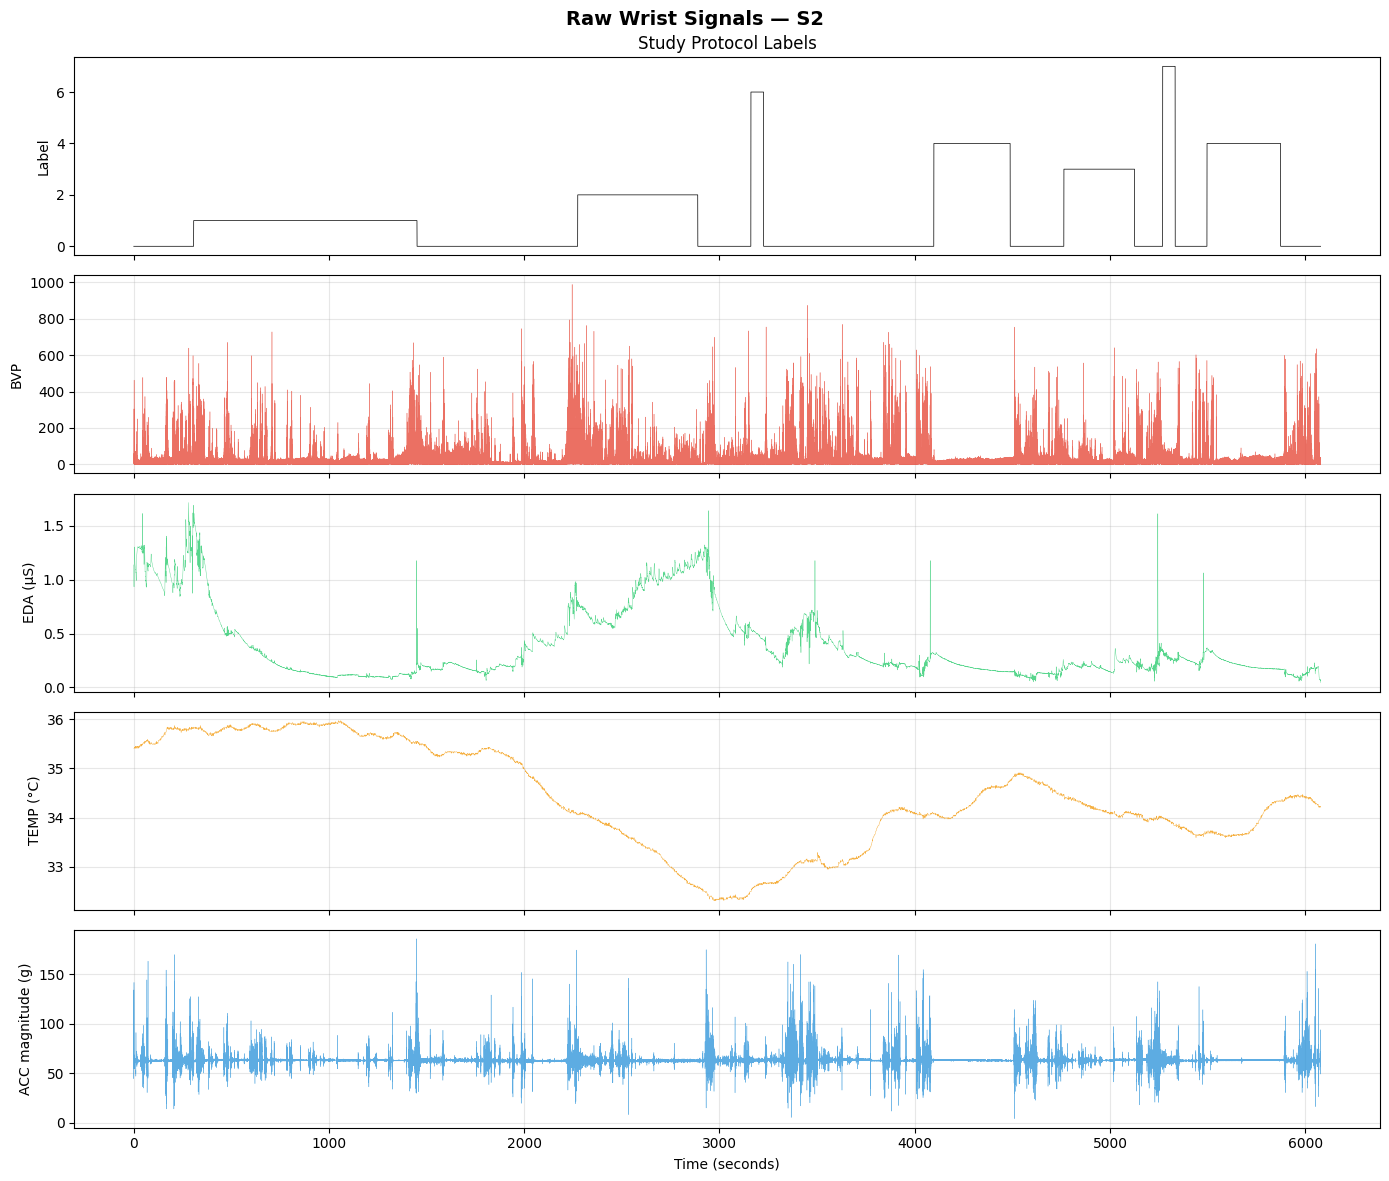

In [9]:
# === Visualize raw wrist signals for one subject ===
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f"Raw Wrist Signals — S{SUBJECT_IDS[0]}", fontsize=14, fontweight='bold')

wrist = sample['signal']['wrist']
labels = sample['label'].flatten()

# Plot labels
t_labels = np.arange(len(labels)) / LABEL_SAMPLING_RATE
axes[0].plot(t_labels, labels, color='black', linewidth=0.5)
axes[0].set_ylabel('Label')
axes[0].set_title('Study Protocol Labels')

# Plot each wrist signal
signal_list = [
    ('BVP', 'BVP', '#e74c3c'),
    ('EDA', 'EDA (μS)', '#2ecc71'),
    ('TEMP', 'TEMP (°C)', '#f39c12'),
    ('ACC', 'ACC magnitude (g)', '#3498db'),
]

for i, (key, ylabel, color) in enumerate(signal_list):
    ax = axes[i + 1]
    sr = WRIST_SAMPLING_RATES[key]
    data = wrist[key]
    if data.ndim > 1:
        data = np.linalg.norm(data, axis=1)
    else:
        data = data.flatten()
    t = np.arange(len(data)) / sr
    ax.plot(t, data, color=color, linewidth=0.3, alpha=0.8)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (seconds)')
plt.tight_layout()
plt.show()


## Section 3: Preprocessing & Windowing

Segment all wrist signals into **5-second** fixed windows. Each window gets a label via **majority vote** from the 700 Hz label stream. Windows with ambiguous labels (majority < 80%) or invalid labels (0, 4–7) are discarded.

Features are extracted at each signal's **native sampling rate** to preserve information.


In [10]:
# === Process all subjects ===
all_windows = {}
all_labels_dict = {}

for sid in SUBJECT_IDS:
    w, l = create_windows(all_subjects_data[sid], WINDOW_SIZE_SEC, WINDOW_SHIFT_SEC, LABEL_SAMPLING_RATE, WRIST_SAMPLING_RATES, VALID_LABELS)
    all_windows[sid] = w
    all_labels_dict[sid] = l
    unique, counts = np.unique(l, return_counts=True)
    dist = ", ".join([f"{LABEL_MAP[int(u)]}={c}" for u, c in zip(unique, counts)])
    print(f"S{sid}: {len(w)} windows ({dist})")

total = sum(len(v) for v in all_windows.values())
print(f"\nTotal windows: {total}")


S2: 413 windows (Baseline=225, Stress=119, Amusement=69)
S3: 419 windows (Baseline=224, Stress=124, Amusement=71)
S4: 422 windows (Baseline=228, Stress=123, Amusement=71)
S5: 432 windows (Baseline=236, Stress=125, Amusement=71)
S6: 430 windows (Baseline=232, Stress=127, Amusement=71)
S7: 429 windows (Baseline=234, Stress=124, Amusement=71)
S8: 430 windows (Baseline=230, Stress=130, Amusement=70)
S9: 429 windows (Baseline=233, Stress=125, Amusement=71)
S10: 444 windows (Baseline=232, Stress=141, Amusement=71)
S11: 435 windows (Baseline=233, Stress=132, Amusement=70)
S13: 435 windows (Baseline=232, Stress=130, Amusement=73)
S14: 435 windows (Baseline=232, Stress=132, Amusement=71)
S15: 436 windows (Baseline=232, Stress=134, Amusement=70)
S16: 433 windows (Baseline=232, Stress=131, Amusement=70)
S17: 444 windows (Baseline=232, Stress=141, Amusement=71)

Total windows: 6466


# Section 4 — Feature Extraction


For each 5-second window, extract **time-domain** and **frequency-domain** features from all wrist signals:
- **Statistical**: mean, std, min, max, median, range, skewness, kurtosis, RMS, mean absolute deviation, sum of absolute differences
- **Frequency**: total power, dominant frequency, spectral entropy (via Welch's method)
- **EDA-specific**: number of peaks, mean peak height, derivative statistics

In [11]:
# === Build the feature matrix ===
print("Extracting features from all windows...")

feature_rows = []
label_rows = []
group_rows = []

for sid in SUBJECT_IDS:
    n = len(all_windows[sid])
    print(f"  S{sid}: {n} windows...", end=" ")
    for window, label in zip(all_windows[sid], all_labels_dict[sid]):
        feature_rows.append(extract_window_features(window, WRIST_SAMPLING_RATES))
        label_rows.append(BINARY_MAP[label])
        group_rows.append(sid)
    print("done")

X = pd.DataFrame(feature_rows)
y = np.array(label_rows)
groups = np.array(group_rows)

# Clean NaN/Inf
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"\nFeature matrix: {X.shape[0]} samples × {X.shape[1]} features")
print(f"Non-Stress: {np.sum(y == 0)}, Stress: {np.sum(y == 1)}")
print(f"\nFeatures ({X.shape[1]}):")
for i, c in enumerate(X.columns, 1):
    print(f"  {i:3d}. {c}")


Extracting features from all windows...
  S2: 413 windows... done
  S3: 419 windows... done
  S4: 422 windows... done
  S5: 432 windows... done
  S6: 430 windows... done
  S7: 429 windows... done
  S8: 430 windows... done
  S9: 429 windows... done
  S10: 444 windows... done
  S11: 435 windows... done
  S13: 435 windows... done
  S14: 435 windows... done
  S15: 436 windows... done
  S16: 433 windows... done
  S17: 444 windows... done

Feature matrix: 6466 samples × 99 features
Non-Stress: 4528, Stress: 1938

Features (99):
    1. ACC_x_mean
    2. ACC_x_std
    3. ACC_x_min
    4. ACC_x_max
    5. ACC_x_median
    6. ACC_x_range
    7. ACC_x_skew
    8. ACC_x_kurtosis
    9. ACC_x_rms
   10. ACC_x_mad
   11. ACC_x_sad
   12. ACC_x_total_power
   13. ACC_x_dom_freq
   14. ACC_x_spectral_entropy
   15. ACC_y_mean
   16. ACC_y_std
   17. ACC_y_min
   18. ACC_y_max
   19. ACC_y_median
   20. ACC_y_range
   21. ACC_y_skew
   22. ACC_y_kurtosis
   23. ACC_y_rms
   24. ACC_y_mad
   25. ACC_y_s

# Section 5. Feature Analysis

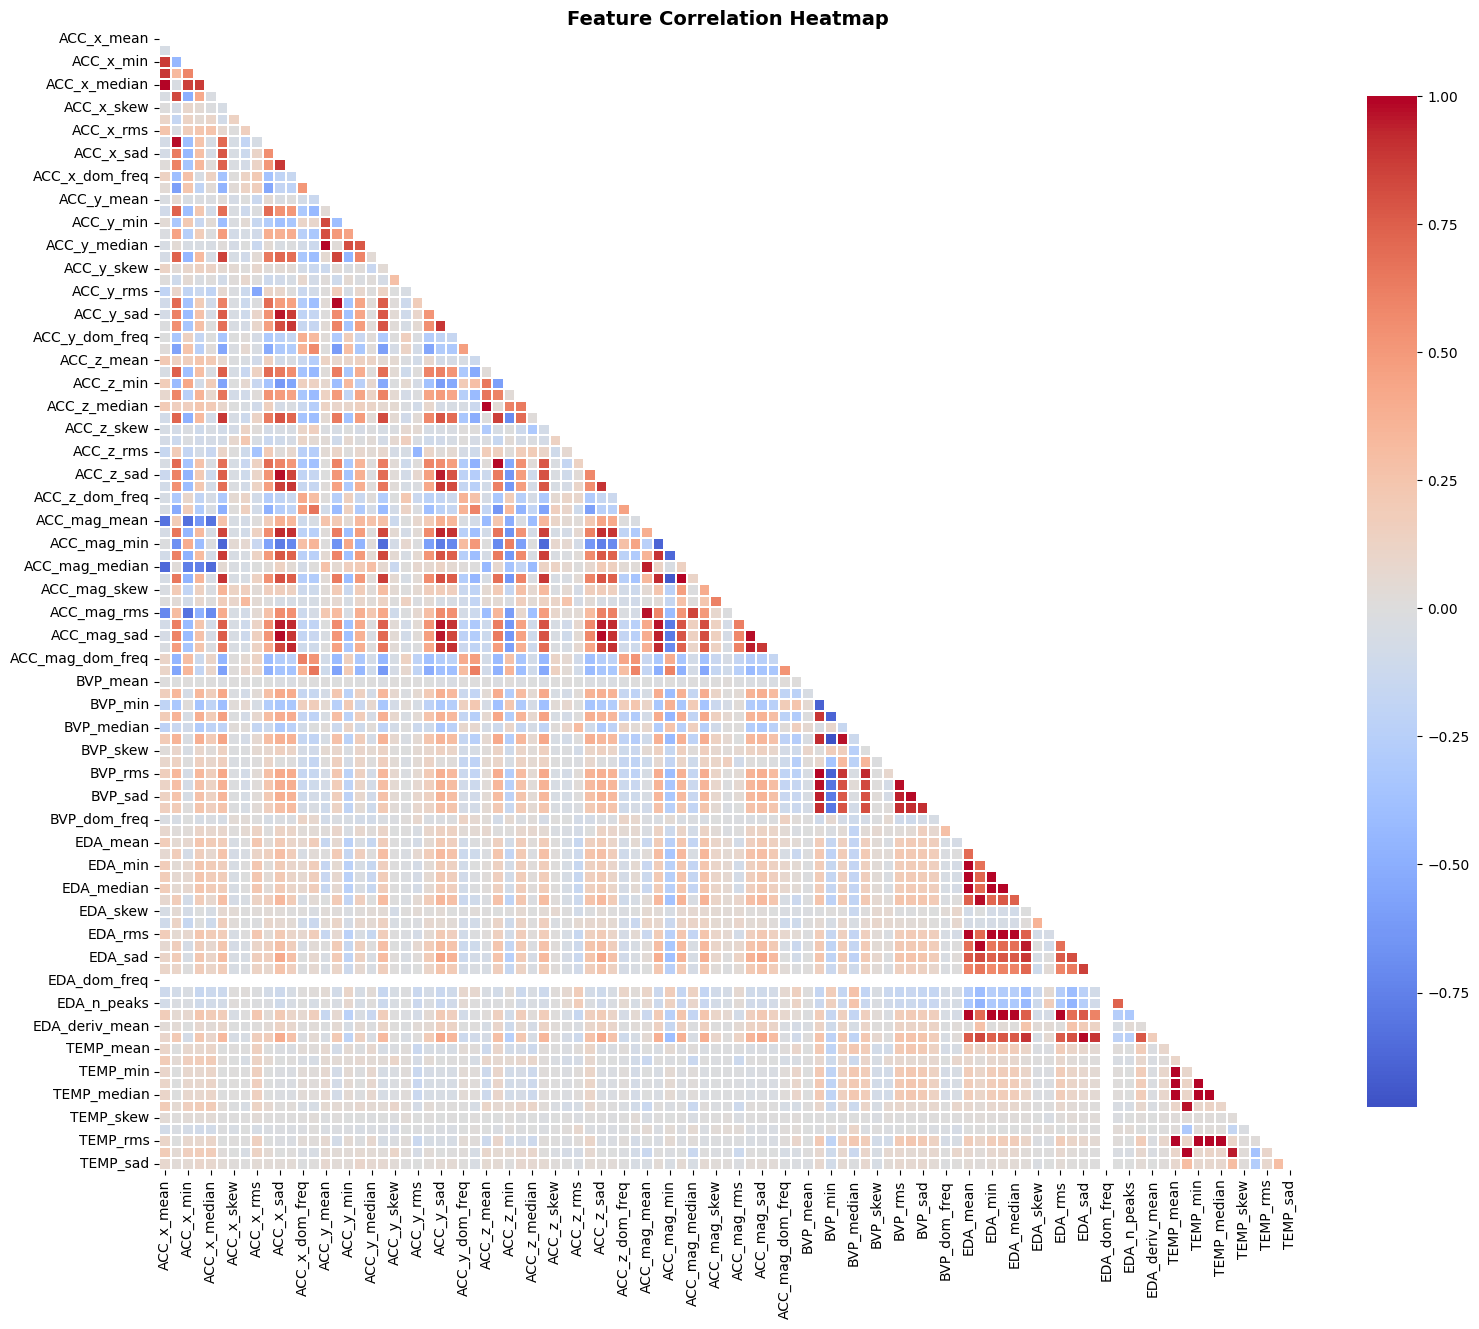

In [12]:
# === Correlation heatmap ===
plt.figure(figsize=(16, 14))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.3, annot=False,
            cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


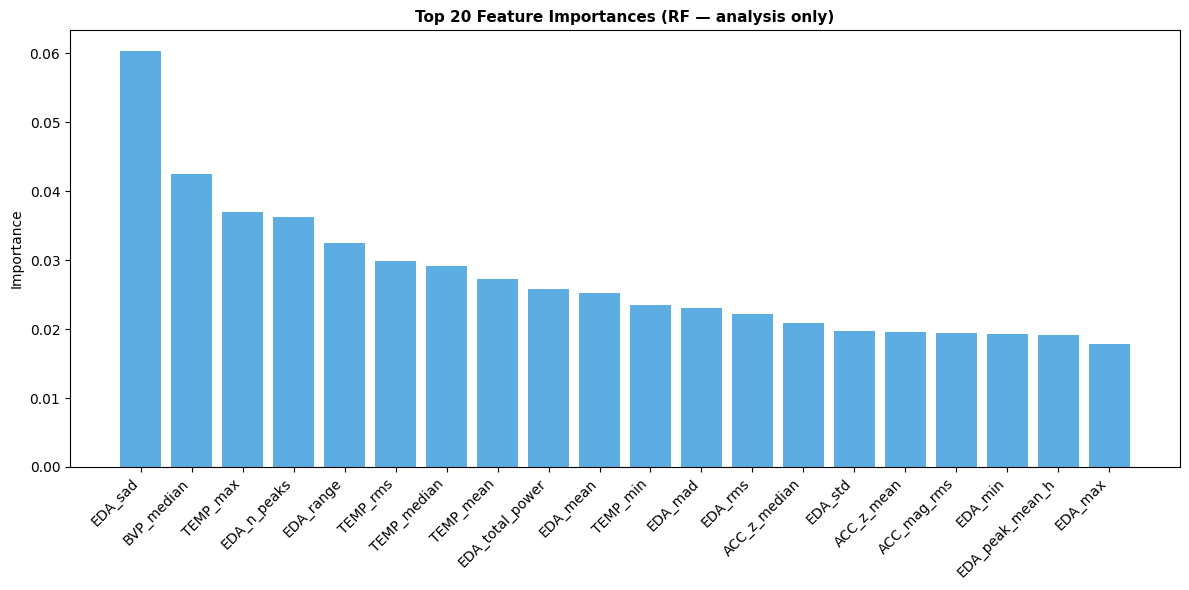

In [13]:
# === Feature importance (quick RF — not a final model) ===
scaler_tmp = StandardScaler()
X_tmp = scaler_tmp.fit_transform(X)

rf_analysis = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_analysis.fit(X_tmp, y)

importances = rf_analysis.feature_importances_
top_idx = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 6))
plt.bar(range(20), importances[top_idx], color='#3498db', alpha=0.8)
plt.xticks(range(20), [X.columns[i] for i in top_idx], rotation=45, ha='right')
plt.title('Top 20 Feature Importances (RF — analysis only)',
          fontsize=11, fontweight='bold')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()


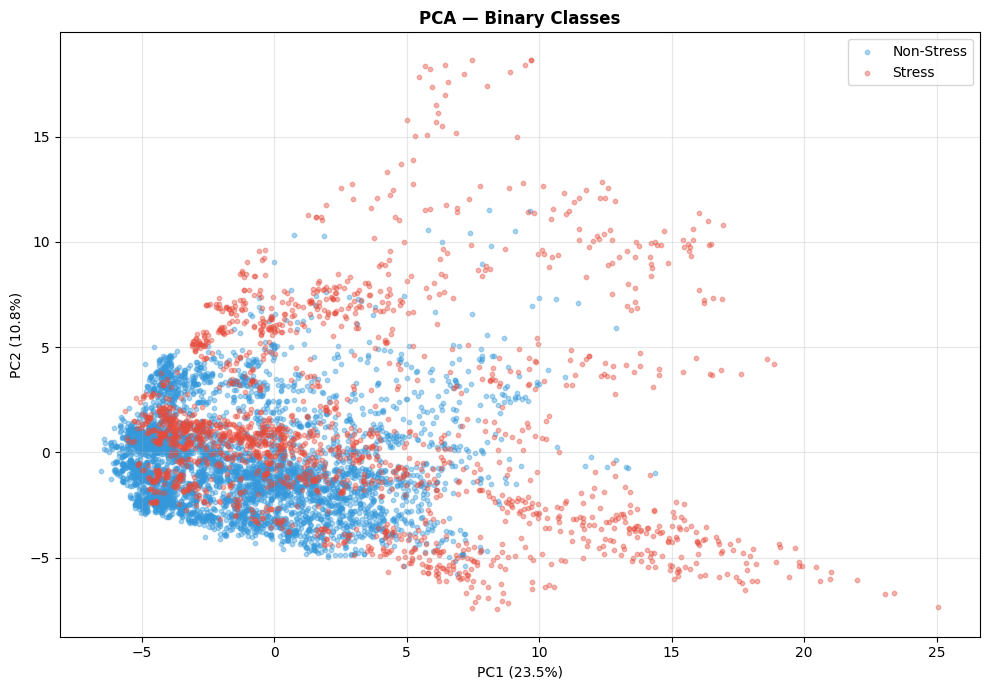

Explained variance (2 PCs): 34.3%


In [14]:
# === PCA Visualization ===
scaler_pca = StandardScaler()
X_pca_in = scaler_pca.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_pca_in)

plt.figure(figsize=(10, 7))
for lv, color, name in zip([0, 1], ['#3498db', '#e74c3c'], BINARY_LABEL_NAMES):
    m = y == lv
    plt.scatter(X_pca[m, 0], X_pca[m, 1], c=color, label=name, alpha=0.4, s=10)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA — Binary Classes', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Explained variance (2 PCs): {sum(pca.explained_variance_ratio_)*100:.1f}%")


# Section 6. Model Development

Models chosen to be **different from the original WESAD paper** (which used DT, RF, AdaBoost, LDA, kNN):
1. **Logistic Regression**
2. **SVM** (RBF kernel)
3. **Gradient Boosting** (sklearn)
4. **MLP** (Multi-Layer Perceptron)

Cross Validation employed for the models is: 

**Leave-One-Subject-Out**: train on 14 subjects, test on 1. Ensures subject-independent evaluation.

In [15]:
# === Define models ===
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42, class_weight='balanced'),
    'SVM (RBF)': SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(128, 64), max_iter=500,
        early_stopping=True, validation_fraction=0.1, random_state=42
    ),
}


In [16]:

# === LOSO CV ===
logo = LeaveOneGroupOut()
results = {name: {'y_true': [], 'y_pred': [], 'y_prob': [], 'subjects': []}
           for name in models}

n_folds = logo.get_n_splits(X, y, groups)
print(f"Running LOSO Cross-Validation ({n_folds} folds)")
print(f"Features: {X.shape[1]}  |  Samples: {X.shape[0]}")
print("=" * 70)

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
    test_subj = groups[test_idx[0]]
    print(f"\nFold {fold+1}/{n_folds}: test on S{test_subj} "
          f"(train={len(train_idx)}, test={len(test_idx)})")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train_imp)
    X_te = scaler.transform(X_test_imp)

    for mname, model in models.items():
        m = clone(model)
        m.fit(X_tr, y_train)
        preds = m.predict(X_te)
        probs = m.predict_proba(X_te)[:, 1]

        results[mname]['y_true'].extend(y_test)
        results[mname]['y_pred'].extend(preds)
        results[mname]['y_prob'].extend(probs)
        results[mname]['subjects'].extend([test_subj] * len(y_test))

        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds)
        print(f"  {mname}: Acc={acc:.3f}, F1={f1:.3f}")

print("\n" + "=" * 70)
print("LOSO Cross-Validation complete!")

Running LOSO Cross-Validation (15 folds)
Features: 99  |  Samples: 6466

Fold 1/15: test on S2 (train=6053, test=413)
  Logistic Regression: Acc=0.668, F1=0.297
  SVM (RBF): Acc=0.826, F1=0.700
  Gradient Boosting: Acc=0.927, F1=0.856
  MLP: Acc=0.789, F1=0.595

Fold 2/15: test on S3 (train=6047, test=419)
  Logistic Regression: Acc=0.714, F1=0.627
  SVM (RBF): Acc=0.826, F1=0.681
  Gradient Boosting: Acc=0.881, F1=0.826
  MLP: Acc=0.850, F1=0.777

Fold 3/15: test on S4 (train=6044, test=422)
  Logistic Regression: Acc=1.000, F1=1.000
  SVM (RBF): Acc=0.972, F1=0.949
  Gradient Boosting: Acc=0.981, F1=0.967
  MLP: Acc=0.991, F1=0.983

Fold 4/15: test on S5 (train=6034, test=432)
  Logistic Regression: Acc=0.882, F1=0.805
  SVM (RBF): Acc=0.831, F1=0.684
  Gradient Boosting: Acc=0.796, F1=0.516
  MLP: Acc=0.919, F1=0.875

Fold 5/15: test on S6 (train=6036, test=430)
  Logistic Regression: Acc=0.907, F1=0.844
  SVM (RBF): Acc=0.602, F1=0.240
  Gradient Boosting: Acc=0.828, F1=0.773
  MLP

# Section 7. Evaluation

In [17]:
# === Overall metrics ===
print("=" * 70)
print("OVERALL MODEL COMPARISON")
print("=" * 70)

comparison = []
for mname in models:
    yt = np.array(results[mname]['y_true'])
    yp = np.array(results[mname]['y_pred'])

    row = {
        'Model': mname,
        'Accuracy': round(accuracy_score(yt, yp), 4),
        'Precision': round(precision_score(yt, yp), 4),
        'Recall': round(recall_score(yt, yp), 4),
        'F1-Score': round(f1_score(yt, yp), 4),
    }
    comparison.append(row)
    print(f"\n--- {mname} ---")
    print(classification_report(yt, yp, target_names=BINARY_LABEL_NAMES))

comp_df = pd.DataFrame(comparison)
print("\nSummary Table:")
print(comp_df.to_string(index=False))


OVERALL MODEL COMPARISON

--- Logistic Regression ---
              precision    recall  f1-score   support

  Non-Stress       0.92      0.91      0.91      4528
      Stress       0.79      0.81      0.80      1938

    accuracy                           0.88      6466
   macro avg       0.85      0.86      0.86      6466
weighted avg       0.88      0.88      0.88      6466


--- SVM (RBF) ---
              precision    recall  f1-score   support

  Non-Stress       0.87      0.90      0.88      4528
      Stress       0.74      0.68      0.71      1938

    accuracy                           0.83      6466
   macro avg       0.80      0.79      0.80      6466
weighted avg       0.83      0.83      0.83      6466


--- Gradient Boosting ---
              precision    recall  f1-score   support

  Non-Stress       0.89      0.93      0.91      4528
      Stress       0.82      0.74      0.78      1938

    accuracy                           0.87      6466
   macro avg       0.86     

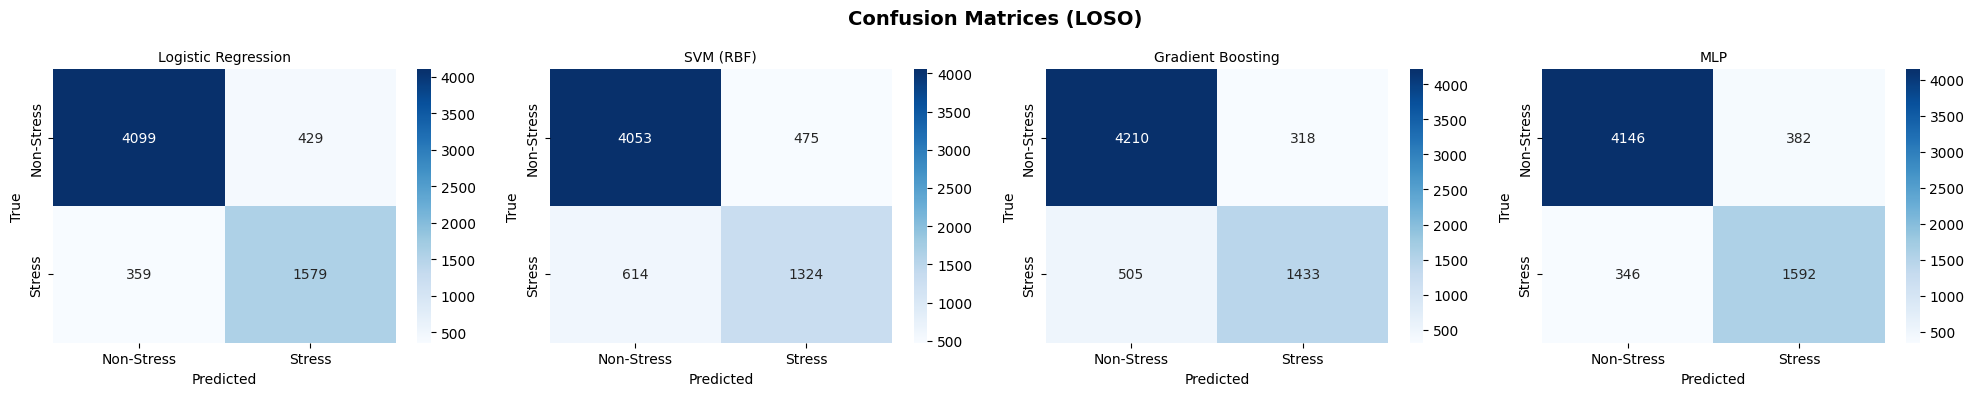

In [18]:
# === Confusion matrices ===
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
fig.suptitle('Confusion Matrices (LOSO)', fontsize=14, fontweight='bold')

for idx, mname in enumerate(models):
    yt = np.array(results[mname]['y_true'])
    yp = np.array(results[mname]['y_pred'])
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=BINARY_LABEL_NAMES, yticklabels=BINARY_LABEL_NAMES)
    axes[idx].set_title(mname, fontsize=10)
    axes[idx].set_ylabel('True')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.show()


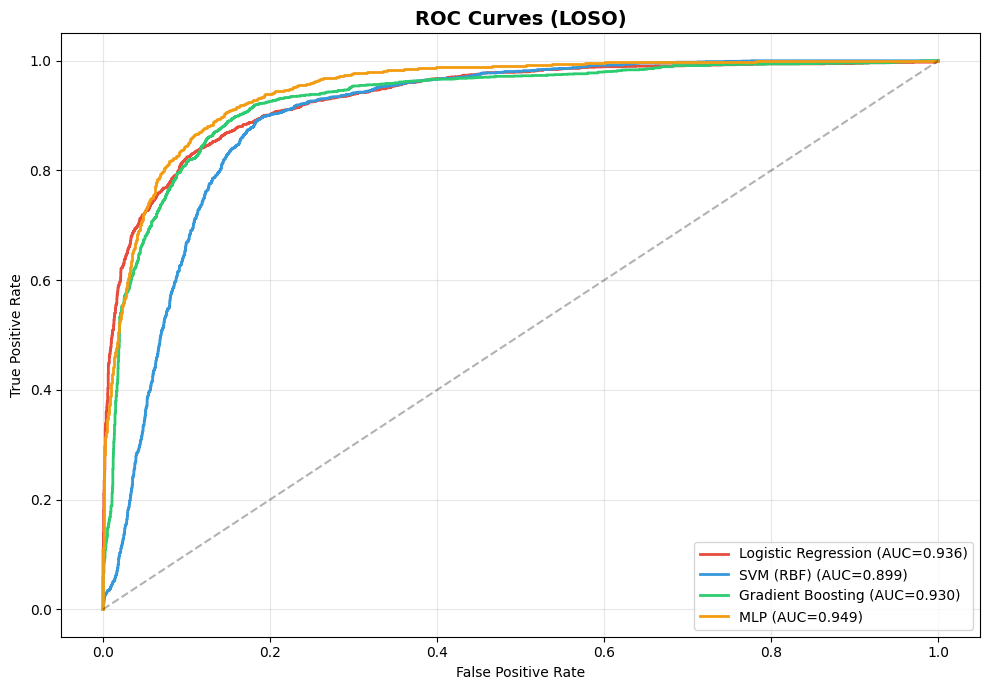

In [19]:
# === ROC Curves ===
plt.figure(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for mname, color in zip(models, colors):
    yt = np.array(results[mname]['y_true'])
    yp = np.array(results[mname]['y_prob'])
    fpr, tpr, _ = roc_curve(yt, yp)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{mname} (AUC={roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (LOSO)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Best model by F1: MLP

Subject  Accuracy     F1  N_samples  Stress_ratio
     S2    0.7893 0.5953        413         0.288
     S3    0.8496 0.7774        419         0.296
     S4    0.9905 0.9835        422         0.291
     S5    0.9190 0.8754        432         0.289
     S6    0.8326 0.7517        430         0.295
     S7    0.6573 0.6278        429         0.289
     S8    0.9465 0.9053        430         0.302
     S9    0.7832 0.4076        429         0.291
    S10    0.9482 0.9139        444         0.318
    S11    0.9908 0.9851        435         0.303
    S13    0.9563 0.9319        435         0.299
    S14    0.8989 0.8000        435         0.303
    S15    0.8739 0.7826        436         0.307
    S16    0.9723 0.9562        433         0.303
    S17    0.8941 0.8082        444         0.318


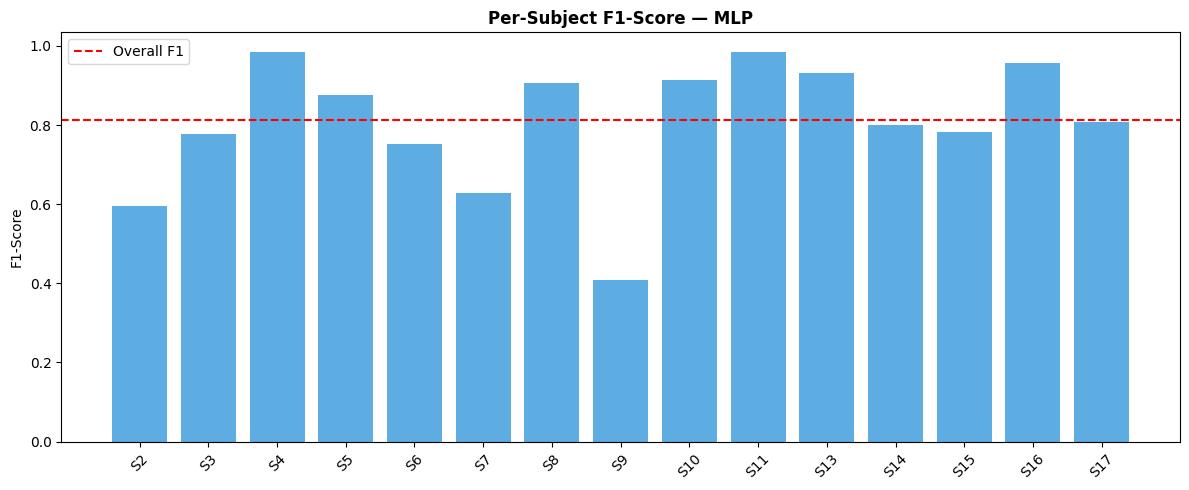

In [20]:
# === Per-subject performance (best model) ===
best_model = comp_df.loc[comp_df['F1-Score'].idxmax(), 'Model']
print(f"Best model by F1: {best_model}\n")

per_subj = []
for sid in SUBJECT_IDS:
    mask = np.array(results[best_model]['subjects']) == sid
    yt = np.array(results[best_model]['y_true'])[mask]
    yp = np.array(results[best_model]['y_pred'])[mask]
    per_subj.append({
        'Subject': f'S{sid}',
        'Accuracy': round(accuracy_score(yt, yp), 4),
        'F1': round(f1_score(yt, yp, zero_division=0), 4),
        'N_samples': len(yt),
        'Stress_ratio': round(np.mean(yt), 3),
    })

per_subj_df = pd.DataFrame(per_subj)
print(per_subj_df.to_string(index=False))

# Plot per-subject F1
plt.figure(figsize=(12, 5))
plt.bar(per_subj_df['Subject'], per_subj_df['F1'], color='#3498db', alpha=0.8)
plt.axhline(y=comp_df.loc[comp_df['Model'] == best_model, 'F1-Score'].values[0],
            color='red', linestyle='--', label='Overall F1')
plt.ylabel('F1-Score')
plt.title(f'Per-Subject F1-Score — {best_model}', fontsize=12, fontweight='bold')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


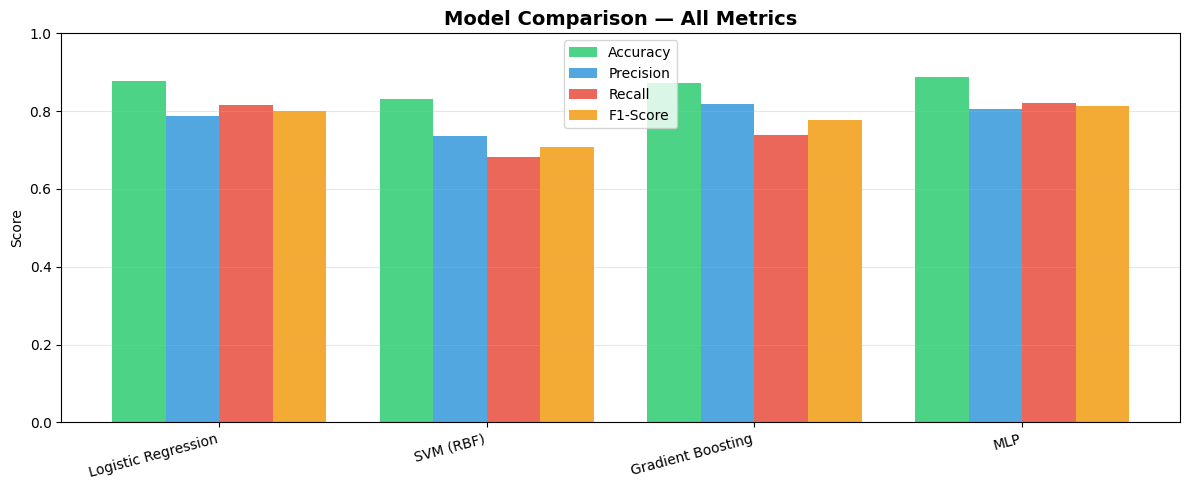

In [21]:
# === Final model comparison bar chart ===
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(comp_df))
width = 0.2
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_bar = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

for i, (metric, color) in enumerate(zip(metrics, colors_bar)):
    ax.bar(x + i * width, comp_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(comp_df['Model'], rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()



## Section 8. Feature Relevance Analysis
As part of the project requirements, we analyze which features are driving the predictions.

In [22]:
print("Training final Gradient Boosting model to analyze feature importance...")
final_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
imputer_final = SimpleImputer(strategy='median')
scaler_final = StandardScaler()
X_imp = imputer_final.fit_transform(X)
X_scaled = scaler_final.fit_transform(X_imp)
final_model.fit(X_scaled, y)



Training final Gradient Boosting model to analyze feature importance...


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

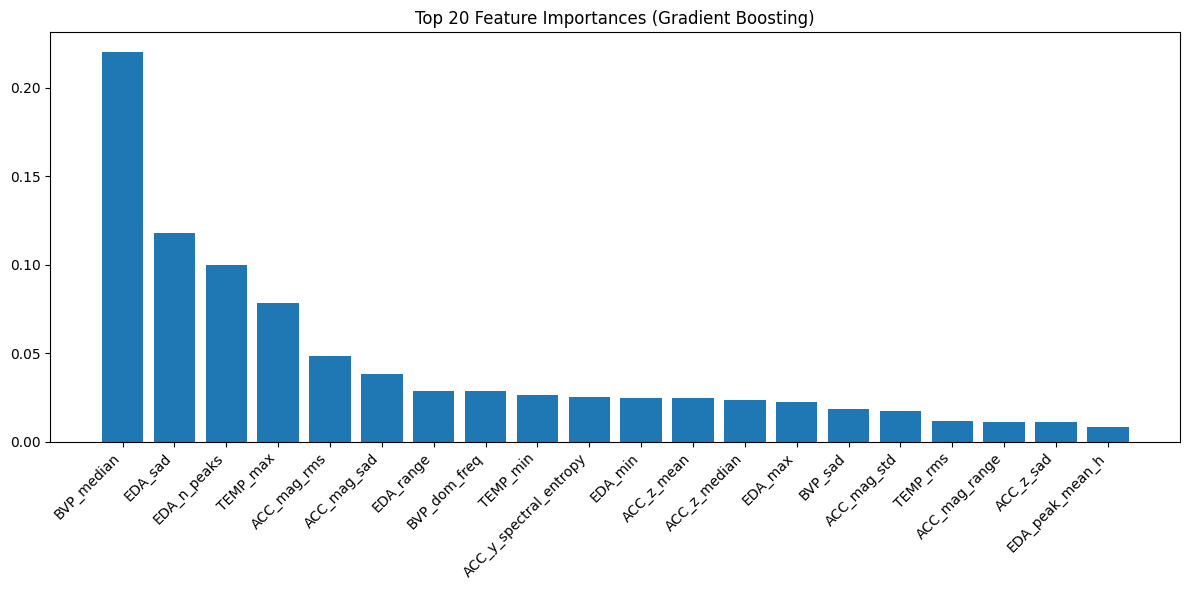

In [23]:
# 1. Traditional Feature Importance
importances = final_model.feature_importances_
indices = np.argsort(importances)[::-1]
top_feature_idx = indices[0]
top_feature_name = X.columns[top_feature_idx]

plt.figure(figsize=(12, 6))
plt.title("Top 20 Feature Importances (Gradient Boosting)")
plt.bar(range(20), importances[indices[:20]], align="center")
plt.xticks(range(20), X.columns[indices[:20]], rotation=45, ha='right')
plt.tight_layout()
plt.show()


Calculating SHAP values for global explainability...


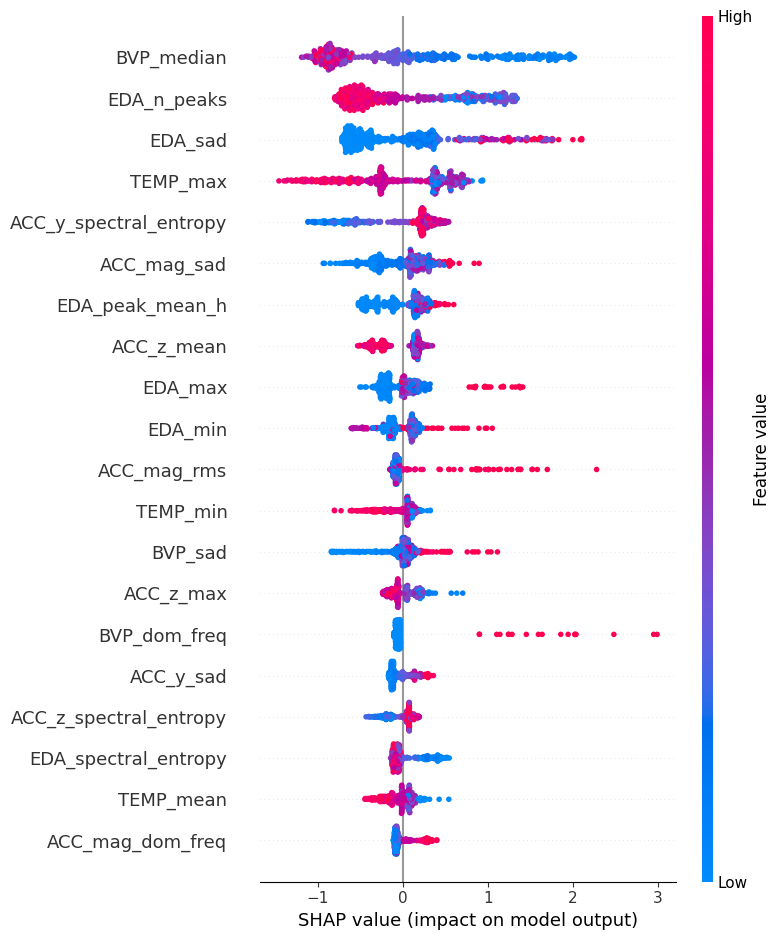

In [24]:

# 2. SHAP Analysis (Explainability)
print("\nCalculating SHAP values for global explainability...")
# Using a subsample for speed
X_sample = shap.utils.sample(X_scaled, 500)
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_sample)
shap.summary_plot(shap_values, features=X_sample, feature_names=X.columns, plot_type="dot")



Analyzing Subject Variability for Top Feature: BVP_median


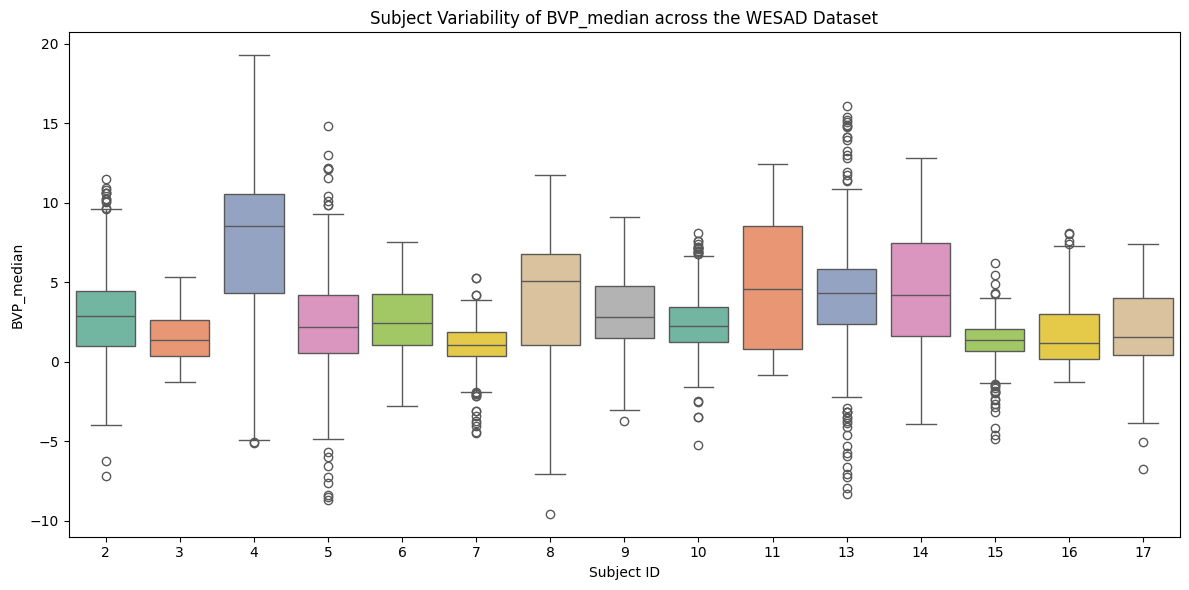

In [25]:


# 3. Subject Variability Plot for Top Feature
print(f"\nAnalyzing Subject Variability for Top Feature: {top_feature_name}")
plt.figure(figsize=(12, 6))
sns.boxplot(x=groups, y=X[top_feature_name], palette='Set2')
plt.title(f"Subject Variability of {top_feature_name} across the WESAD Dataset")
plt.xlabel("Subject ID")
plt.ylabel(top_feature_name)
plt.tight_layout()
plt.show()


Section 9 — Advanced AI / Extensions (Bonus)
Feature selection (e.g., mutual information, recursive feature elimination)
Personalization vs. general models discussion
Robustness to noise analysis
Potential deep learning approach (CNN on raw signals or LSTM)


Section 10 — SoA Analysis & Critical Discussion
State-of-the-art analysis
Data access & quality considerations
Explainability discussion
Ethical considerations & GDPR
Challenges of AI in healthcare
Journal club checklist integration